In [1]:
import scanpy as sc
import harmonypy as hm
from utils import median_rank_shift
import numpy as np


## Load the data

In [2]:
adata = sc.read_h5ad("dataset.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 2155 × 9842
    obs: 'batch', 'cell_type'
    var: 'gene'

## Anndata object

![](img/anndata_diagram.png)

In [4]:
adata.obs

,batch,cell_type
index,,
GCTCCTATCTATCGCC-1-Oetjen_A,Oetjen_A,CD4+ T cells
CATCAGAGTAAGTTCC-1-Oetjen_A,Oetjen_A,CD14+ Monocytes
CAGCATAGTGGTCCGT-1-Sun_sample1_CS,Sun_sample1_CS,CD4+ T cells
TCGTACCAGAGTAATC-1-Oetjen_A,Oetjen_A,NKT cells
TCAGGTACAGAGTGTG-1-Oetjen_A,Oetjen_A,CD14+ Monocytes
...,...,...
ATTACTCAGTGAATTG-1-Sun_sample1_CS,Sun_sample1_CS,CD4+ T cells
CCTTACGGTAAAGTCA-1-Oetjen_A,Oetjen_A,CD20+ B cells
ATTACTCTCCATGCTC-1-Sun_sample1_CS,Sun_sample1_CS,CD4+ T cells


In [5]:
adata.var

,gene
index,
ZBTB5,ZBTB5
HAUS7,HAUS7
DAP3,DAP3
KLHL9,KLHL9
RAB20,RAB20
...,...
ZNF579,ZNF579
ATP6V1C2,ATP6V1C2
GRK5,GRK5


In [6]:
adata.obs["batch"].value_counts()

batch
Oetjen_A          1318
Sun_sample1_CS     837
Name: count, dtype: int64

## Single Cell Workflow

1. Quality control and filtering
2. Normalization
3. Feature selection
4. Dimensionality reduction

QC, Filtering, and Normalization have already been done.

Now we need to identify variable genes and perform dimensionality reduction with PCA.

Batch correction will be performed on these lower dimensional PC scores. 




In [7]:
sc.pp.highly_variable_genes(adata)
sc.tl.pca(adata)

## Impact of Batch Effects

Before doing batch correction, we can see how batch effects are impacting our data by computing a neighborhood graph and visualizing with UMAP.


##

In [8]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

### UMAP with neighborhood graph edges

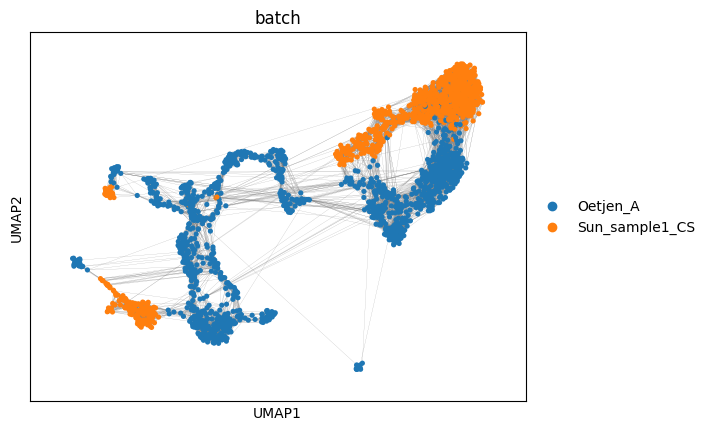

In [9]:
sc.pl.umap(adata, color="batch", edges=True, edges_width=0.1)

### UMAP
Plot UMAP with cells colored by batch and by cell type to illustrate batch effects.

Cell type is generally not known before hand. This illustrates the challenge in identifying cells when data are impacted by batch effects.

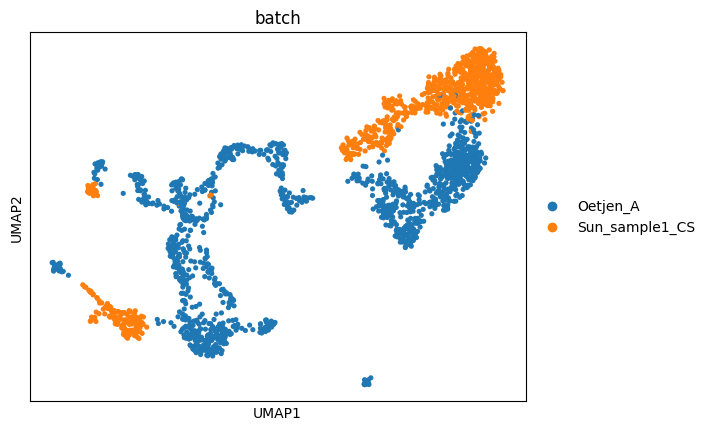

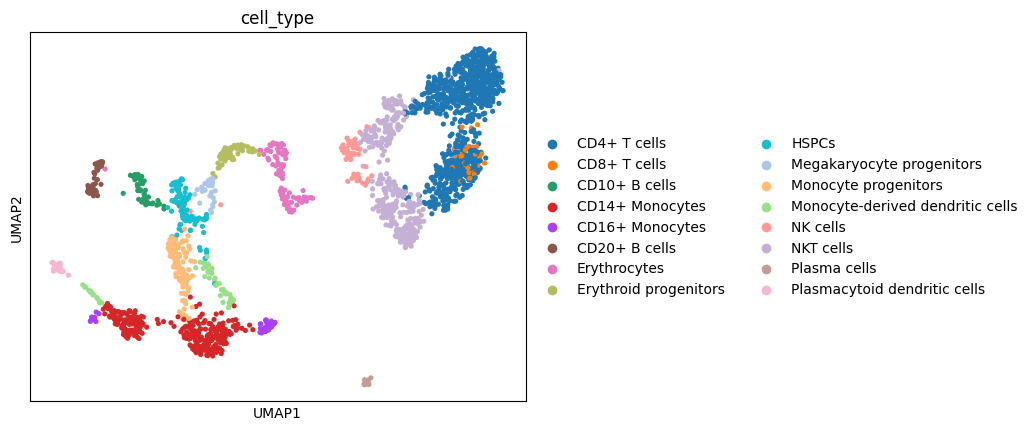

In [10]:
sc.pl.umap(adata, color="batch") 
sc.pl.umap(adata, color="cell_type")

## Harmony

Harmony iteratively adjusts PC scores to remove batch effects while preserving biological variation. The corrected PC scores (`X_pca_harmony`) replace the original PCA for downstream nearest neighbor graph and UMAP computation.

In [11]:
harmony_out = hm.run_harmony(adata.obsm["X_pca"], adata.obs, "batch")

2026-05-22 02:13:25,282 - harmonypy - INFO - Running Harmony
2026-05-22 02:13:25,282 - harmonypy - INFO -   Parameters:
2026-05-22 02:13:25,283 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-22 02:13:25,283 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-22 02:13:25,283 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-22 02:13:25,284 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-22 02:13:25,284 - harmonypy - INFO -     nclust: 72
2026-05-22 02:13:25,284 - harmonypy - INFO -     block_size: 0.05
2026-05-22 02:13:25,284 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-22 02:13:25,284 - harmonypy - INFO -     theta: [2. 2.]
2026-05-22 02:13:25,285 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-22 02:13:25,285 - harmonypy - INFO -     verbose: True
2026-05-22 02:13:25,286 - harmonypy - INFO -     random_state: 0
2026-05-22 02:13:25,287 - harmonypy - INFO -   Data: 50 PCs × 2155 cells
2026-05-22 02:13:25,288 - harmonypy - INFO -   Batch

In [12]:
adata.obsm["X_pca_harmony"] = harmony_out.Z_corr

## Evaluating Batch Correction
With batch corrected PC scores we can visualize the impact this might have for clustering.

We recompute the nearest neighbor graph using the corrected PC scores and then visualize again with UMAP.

In [13]:
sc.pp.neighbors(adata, n_pcs=25, use_rep="X_pca_harmony")
sc.tl.umap(adata)

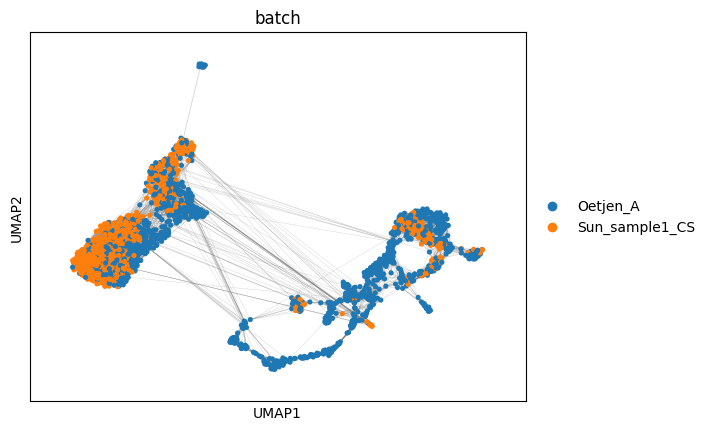

In [14]:
sc.pl.umap(adata, color="batch", edges=True, edges_width=0.1)

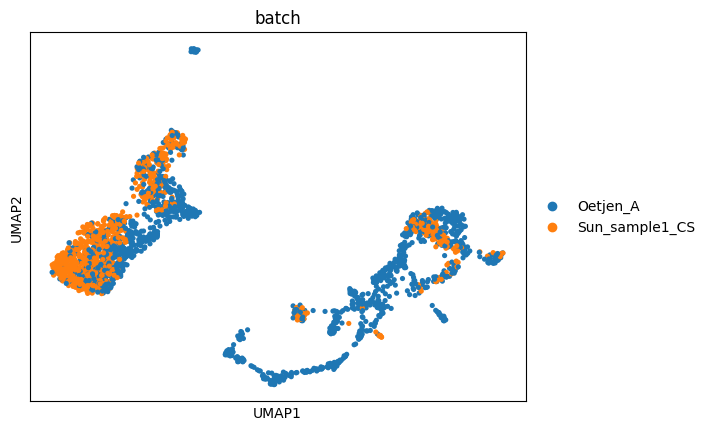

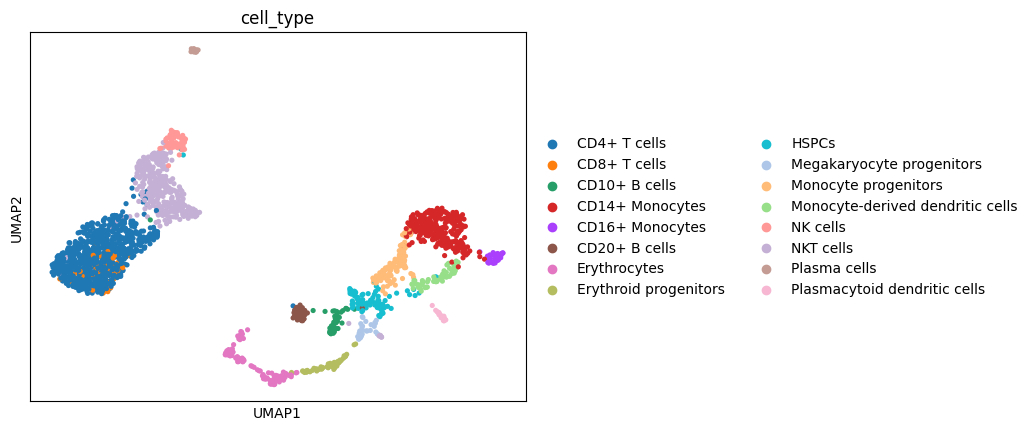

In [15]:
sc.pl.umap(adata, color="batch") 
sc.pl.umap(adata, color="cell_type")

## Quantifying Batch Correction

### Median Rank Shift Score

Taken from: 

[Antonsson SE, Melsted P. Batch correction methods used in single-cell RNA sequencing analyses are often poorly calibrated. Genome Res. 2025. doi: 10.1101/gr.279886.124.](https://doi.org/10.1101/gr.279886.124)

Compute median absolute difference in rank of each cells nearest neighbors before and after batch correction.

Consider a reference cell with 10 neighbors ranked by distance in the original embedding:

![](img/nn_scatter_fig.png)

![](img/median_rank_shift_fig.png)

For each original neighbor, we look up its rank in the corrected order and compute the absolute difference:

| Cell | Original rank | Corrected rank | \|Δ rank\| |
|------|:---:|:---:|:---:|
| 1 | 1 | 3 | 2 |
| 2 | 2 | 8 | 6 |
| 3 | 3 | 1 | 2 |
| 4 | 4 | 9 | 5 |
| 5 | 5 | 5 | 0 |
| 6 | 6 | 6 | 0 |
| 7 | 7 | 7 | 0 |
| 8 | 8 | 2 | 6 |
| 9 | 9 | 4 | 5 |
| 10 | 10 | 10 | 0 |

Sorted absolute shifts: 0, 0, 0, 0, 2, 2, 5, 5, 6, 6

**Median rank shift = 2.0**

### median_rank_shift
I wrote a function called `median_rank_shift` to compute this which is imported from utils.py. We will use it to compute the median rank shift score for each cell in the dataset.

In [16]:
adata.obs["mrs_score"] = median_rank_shift(adata.obsm["X_pca"], adata.obsm["X_pca_harmony"])

### Plotting MRS scores

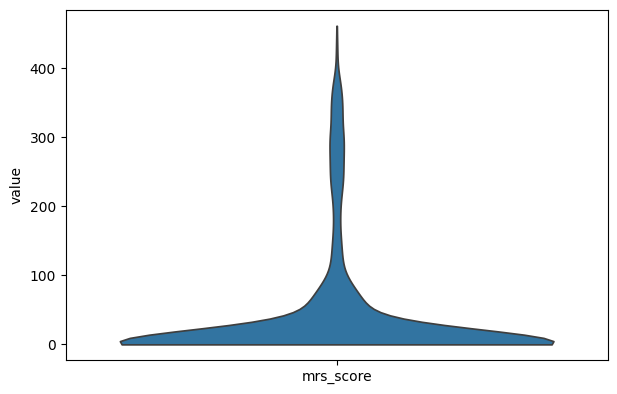

In [17]:
sc.pl.violin(adata, "mrs_score", stripplot=False)

## Batch Correction Without Batch Effects
Whether or not a dataset is impacted by batch effects is generally unknowable. What happens to data if we run batch correction and there is no technical batch variation? 

Let's try it on each of the datasets individually where we create random fake "batches" and then compute the MRS score for each.

In [18]:
adata_oetjen = adata[adata.obs["batch"] == "Oetjen_A"].copy()
adata_oetjen.obs["pseudobatch"] = np.random.choice(["A", "B"], size=len(adata_oetjen))
sc.pp.highly_variable_genes(adata_oetjen)
sc.tl.pca(adata_oetjen)
adata_oetjen.obsm["X_pca_harmony"] = hm.run_harmony(adata_oetjen.obsm["X_pca"], adata_oetjen.obs, "pseudobatch").Z_corr
adata_oetjen.obs["mrs_score"] = median_rank_shift(adata_oetjen.obsm["X_pca"], adata_oetjen.obsm["X_pca_harmony"])

adata_sun = adata[adata.obs["batch"] == "Sun_sample1_CS"].copy()
adata_sun.obs["pseudobatch"] = np.random.choice(["A", "B"], size=len(adata_sun))
sc.pp.highly_variable_genes(adata_sun)
sc.tl.pca(adata_sun)
adata_sun.obsm["X_pca_harmony"] = hm.run_harmony(adata_sun.obsm["X_pca"], adata_sun.obs, "pseudobatch").Z_corr
adata_sun.obs["mrs_score"] = median_rank_shift(adata_sun.obsm["X_pca"], adata_sun.obsm["X_pca_harmony"])


2026-05-22 02:13:27,929 - harmonypy - INFO - Running Harmony
2026-05-22 02:13:27,929 - harmonypy - INFO -   Parameters:
2026-05-22 02:13:27,930 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-22 02:13:27,930 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-22 02:13:27,930 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-22 02:13:27,931 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-22 02:13:27,931 - harmonypy - INFO -     nclust: 44
2026-05-22 02:13:27,931 - harmonypy - INFO -     block_size: 0.05
2026-05-22 02:13:27,931 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-22 02:13:27,932 - harmonypy - INFO -     theta: [2. 2.]
2026-05-22 02:13:27,932 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-22 02:13:27,933 - harmonypy - INFO -     verbose: True
2026-05-22 02:13:27,933 - harmonypy - INFO -     random_state: 0
2026-05-22 02:13:27,933 - harmonypy - INFO -   Data: 50 PCs × 1318 cells
2026-05-22 02:13:27,934 - harmonypy - INFO -   Batch

### Plotting MRS Scores
We can see that there has been very little change to the individual datasets which is good! It means Harmony is not prone to altering biological variation. 

Harmony has been shown to be one of the best methods in this regard in addition to performing well in benchmarks that measure effectiveness in correcting for technical variation.

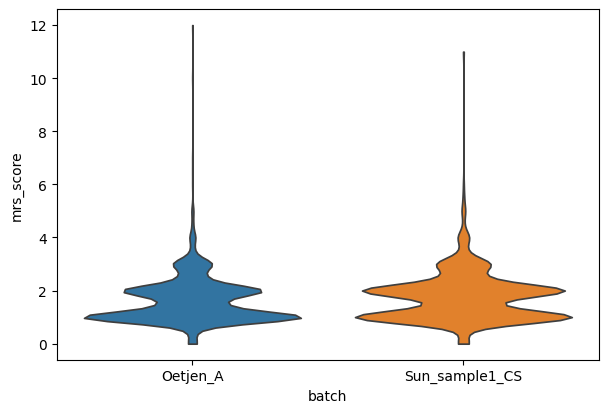

In [19]:
adata_concat = sc.concat([adata_oetjen, adata_sun], join="outer", merge="same")
sc.pl.violin(adata_concat, keys="mrs_score", groupby="batch", stripplot=False)


## ComBat

ComBat is another popular and well performing batch correction tool. ComBat directly from the expression matrix. As we did above, we can look at how ComBat performs.

ComBat appears to do nearly as good of a job as Harmonly

<!-- ComBat consumes to much memory for running in Binder instance so randomly subsampling. -->

Found 154 genes with zero variance.


/Users/kerry.cobb/.miniforge/envs/cu-interview/lib/python3.14/site-packages/scanpy/preprocessing/_combat.py:360: RuntimeWarning: invalid value encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
/Users/kerry.cobb/.miniforge/envs/cu-interview/lib/python3.14/site-packages/scanpy/preprocessing/_combat.py:360: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


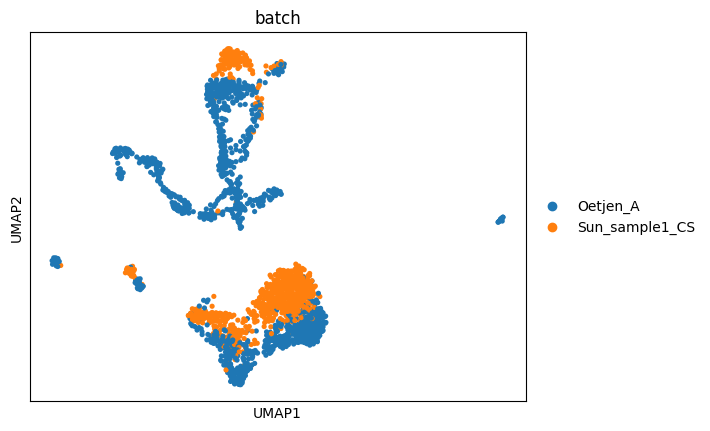

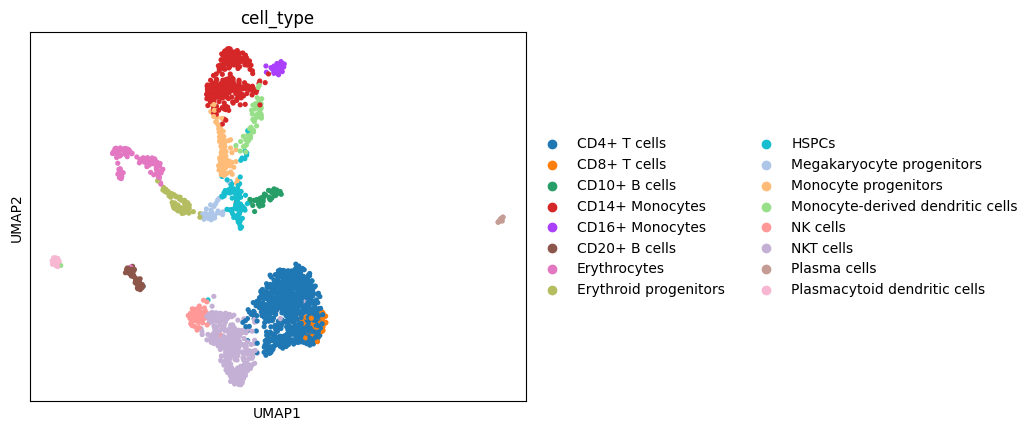

In [20]:
# ComBat corrects X (expression matrix) in place
sc.pp.combat(adata, key="batch")
sc.tl.pca(adata, key_added="X_pca_combat")
sc.pp.neighbors(adata, use_rep="X_pca_combat")
sc.tl.umap(adata)
sc.pl.umap(adata, color="batch") 
sc.pl.umap(adata, color="cell_type")


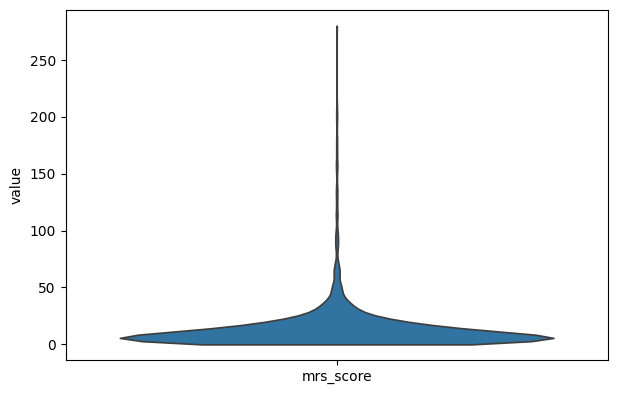

In [21]:
adata.obs["mrs_score"] = median_rank_shift(
    adata.obsm["X_pca"],
    adata.obsm["X_pca_combat"],
)
sc.pl.violin(adata, "mrs_score", stripplot=False)


### ComBat Without Batch Effects

ComBat does appear to have little impact on true biological variation, performing nearly as well as Harmony in this regard.

In [22]:
def run_combat_pseudobatch(adata_full, batch_name):
    adata_s = adata_full[adata_full.obs["batch"] == batch_name].copy()
    adata_s.obs["pseudobatch"] = np.random.choice(["A", "B"], size=len(adata_s))
    sc.pp.highly_variable_genes(adata_s)
    sc.tl.pca(adata_s)
    X_pca_orig = adata_s.obsm["X_pca"].copy()
    sc.pp.combat(adata_s, key="pseudobatch")
    sc.tl.pca(adata_s)
    adata_s.obs["mrs_score"] = median_rank_shift(X_pca_orig, adata_s.obsm["X_pca"])
    return adata_s

adata_oetjen_combat = run_combat_pseudobatch(adata, "Oetjen_A")
adata_sun_combat = run_combat_pseudobatch(adata, "Sun_sample1_CS")


/Users/kerry.cobb/.miniforge/envs/cu-interview/lib/python3.14/site-packages/scanpy/preprocessing/_highly_variable_genes.py:382: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)


Found 154 genes with zero variance.


/Users/kerry.cobb/.miniforge/envs/cu-interview/lib/python3.14/site-packages/scanpy/preprocessing/_combat.py:360: RuntimeWarning: invalid value encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
/Users/kerry.cobb/.miniforge/envs/cu-interview/lib/python3.14/site-packages/scanpy/preprocessing/_combat.py:360: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
/Users/kerry.cobb/.miniforge/envs/cu-interview/lib/python3.14/site-packages/scanpy/preprocessing/_highly_variable_genes.py:382: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/Users/kerry.cobb/.miniforge/envs/cu-interview/lib/python3.14/site-packages/scanpy/preprocessing/_combat.py:360: RuntimeWarning: invalid value encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
/Users/kerry.cobb/.miniforge/envs/cu-interview/lib/python3.14/site-package

Found 154 genes with zero variance.


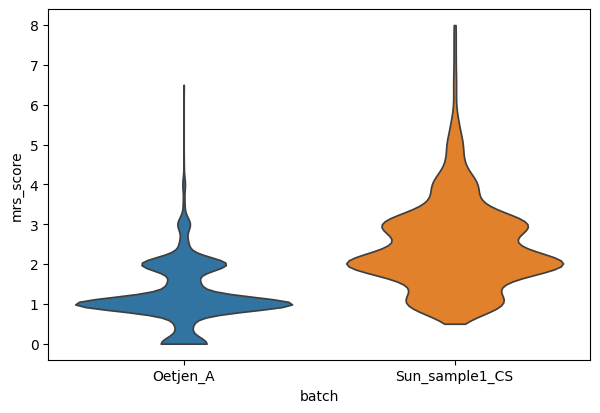

In [23]:
adata_concat_combat = sc.concat(
    [adata_oetjen_combat, adata_sun_combat],
    join="outer",
    merge="same",
)
sc.pl.violin(adata_concat_combat, keys="mrs_score", groupby="batch", stripplot=False)
